<a href="https://colab.research.google.com/github/igauravkumarjha/machine-learning/blob/main/end_to_end_toy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('/content/placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [5]:
df.shape

(100, 4)

In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [8]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [9]:
import matplotlib.pyplot as plt


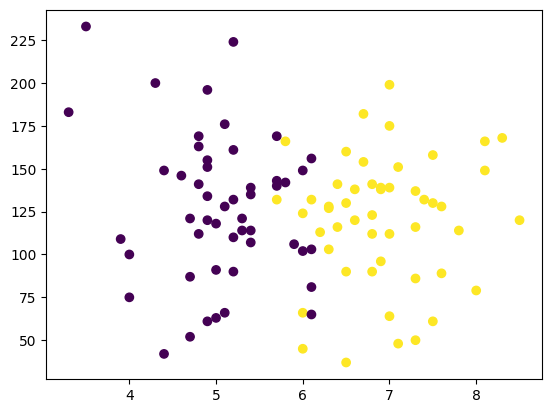

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y.shape

(100,)

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [15]:
X_train

,cgpa,iq
81,5.4,107.0
27,6.0,124.0
69,8.5,120.0
83,7.5,130.0
26,7.0,199.0
...,...,...
14,6.1,103.0
10,6.0,45.0
77,7.3,50.0
13,6.4,116.0


In [16]:
y_train

,placement
81,0
27,1
69,1
83,1
26,1
...,...
14,0
10,1
77,1
13,1


In [17]:
X_test

,cgpa,iq
34,4.8,163.0
71,6.1,132.0
37,8.1,149.0
94,4.7,52.0
32,7.0,139.0
50,3.5,233.0
65,8.1,166.0
91,7.5,158.0
79,6.5,90.0
70,6.3,127.0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[-0.51328322, -0.37996117],
       [ 0.03557408,  0.06078226],
       [ 2.32247951, -0.04292207],
       [ 1.40771734,  0.21633877],
       [ 0.95033625,  2.00523859],
       [ 0.49295517, -2.19478708],
       [-0.23885457,  0.47559962],
       [-1.06214052,  0.5015257 ],
       [ 0.03557408, -1.44293063],
       [ 0.31000274,  0.1644866 ],
       [-0.51328322,  0.44967353],
       [ 0.49295517,  0.9941213 ],
       [ 1.86509842, -1.10589153],
       [ 1.68214599, -0.19847858],
       [-0.9706643 , -0.04292207],
       [ 0.95033625, -1.4947828 ],
       [-0.87918808, -0.09477424],
       [-1.15361674, -0.01699599],
       [-0.60475943, -0.01699599],
       [ 0.6759076 ,  0.8385648 ],
       [-0.78771187, -1.44293063],
       [-0.78771187,  0.1644866 ],
       [-0.69623565, -0.82070461],
       [ 1.2247649 , -0.92440894],
       [-0.9706643 ,  0.86449088],
       [-0.51328322, -0.19847858],
       [-0.9706643 ,  1.92746034],
       [ 0.6759076 ,  1.56449516],
       [-0.78771187,

In [22]:
X_test = scaler.transform(X_test)

In [23]:
X_test

array([[-1.06214052,  1.07189956],
       [ 0.1270503 ,  0.26819094],
       [ 1.95657464,  0.70893437],
       [-1.15361674, -1.80589581],
       [ 0.95033625,  0.44967353],
       [-2.25133134,  2.88672546],
       [ 1.95657464,  1.14967781],
       [ 1.40771734,  0.94226913],
       [ 0.49295517, -0.82070461],
       [ 0.31000274,  0.13856052]])

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
clf = LogisticRegression()

In [26]:
# model training
clf.fit(X_train,y_train)

LogisticRegression()

In [35]:
y_pred = clf.predict(X_test)

In [28]:
y_test

,placement
34,0
71,1
37,1
94,0
32,1
50,0
65,1
91,1
79,1
70,1


In [36]:
from sklearn.metrics import accuracy_score

In [37]:
accuracy_score(y_test,y_pred)

1.0

In [38]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

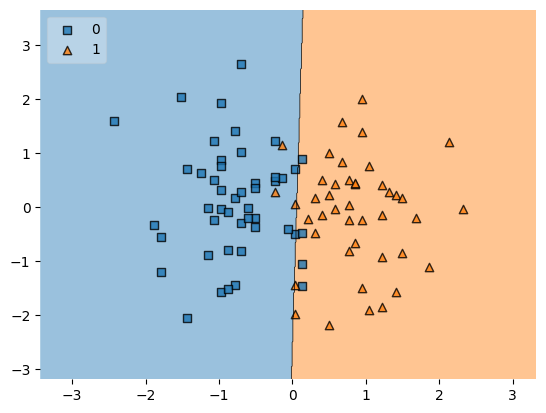

In [39]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [40]:
import pickle

In [41]:
pickle.dump(clf,open('model.pkl','wb'))